# SA Gulfs — HAB Region Sea State Explorer

Combines 8 AODN datasets to characterise sea conditions in the **South Australian Gulfs HAB monitoring region** (134–141.5°E, 34–39.5°S):

| Dataset | Type | Coverage | Key variables |
|---|---|---|---|
| Satellite SST (GHRSST L3S) | Zarr | 2012–2025 | SST (°C) |
| Satellite Chl-a (MODIS Aqua Carder) | Zarr | 2002–2022 | chl_carder (mg/m³) |
| HF Radar currents (SAG) | Zarr | 2009–2024 | U, V surface currents |
| HF Radar waves (SAG) | Zarr | 2011–2020 | VAVH, WPPE |
| Moorings — hourly timeseries | Parquet | 2006–2025 | T, S at 6 sites (36–521 m) |
| Argo floats — core profiles | Parquet | 2010–2022 | T, S to ~2000 m |
| Slocum glider | Parquet | 2008–2024 | T, S, Chl (if available) |
| Wave buoy (realtime) | Parquet | Sep 2022–present | wave height, period |

> **Usage:** Edit the `USER PARAMETERS` cell below, then *Run All*.


---
## 0 · Setup

In [1]:
import os, requests, importlib.util

open('setup.py', 'w').write(
    requests.get('https://raw.githubusercontent.com/aodn/aodn_cloud_optimised/main/notebooks/setup.py').text
)
spec = importlib.util.spec_from_file_location("setup", "setup.py")
setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(setup)
setup.install_requirements()
setup.load_dataquery()


✅ Virtual environment already exists, skipping creation.


Using Python 3.12.11 environment at: /home/lbesnard/miniforge3/envs/AodnCloudOptimised
Resolved 241 packages in 79ms
Audited 241 packages in 2ms


✅ Local version 0.3.9 is up to date (remote: 0.3.9)


In [2]:
import warnings; warnings.filterwarnings('ignore')
import calendar, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr, s3fs
from DataQuery import GetAodn, plot_ts_diagram
aodn = GetAodn()


---
## 1 · User Parameters

Edit this cell to change the analysis period and region.

In [3]:
# ════════════════════════════════════════════════════════════
#  USER PARAMETERS  —  edit here, then Run All
# ════════════════════════════════════════════════════════════
ANALYSIS_MONTH = 4        # Month to analyse (1=Jan … 12=Dec)
YEAR_START     = 2015     # First year (inclusive)
YEAR_END       = 2022     # Last year  (inclusive)

# SA Gulfs HAB bounding box
LAT_MIN, LAT_MAX = -39.5, -34.0
LON_MIN, LON_MAX =  134.0, 141.5
# ════════════════════════════════════════════════════════════

MONTH_NAME = calendar.month_name[ANALYSIS_MONTH]
YEARS      = list(range(YEAR_START, YEAR_END + 1))
# last day of the analysis month (handles variable month lengths)
LAST_DAY   = calendar.monthrange(YEAR_END, ANALYSIS_MONTH)[1]

print(f"Analysing : {MONTH_NAME} {YEAR_START}–{YEAR_END}")
print(f"Region    : {LAT_MIN}°–{LAT_MAX}°S, {LON_MIN}°–{LON_MAX}°E")
print(f"Years     : {YEARS}")



# Safe month-end helper — avoids day-of-month overflow (e.g. April 31)
def _next_month_start(yr, m):
    """Return np.datetime64 of first day of the month AFTER (yr, m)."""
    ts = pd.Timestamp(year=yr, month=m, day=1) + pd.DateOffset(months=1)
    return np.datetime64(ts.strftime('%Y-%m-%d'))

Analysing : April 2015–2022
Region    : -39.5°–-34.0°S, 134.0°–141.5°E
Years     : [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]


---
## 2 · Dataset Discovery Map

Overview of all datasets available in the SA Gulfs HAB region.
Mooring sites are shown as triangles; the HF radar domain as a dashed rectangle.


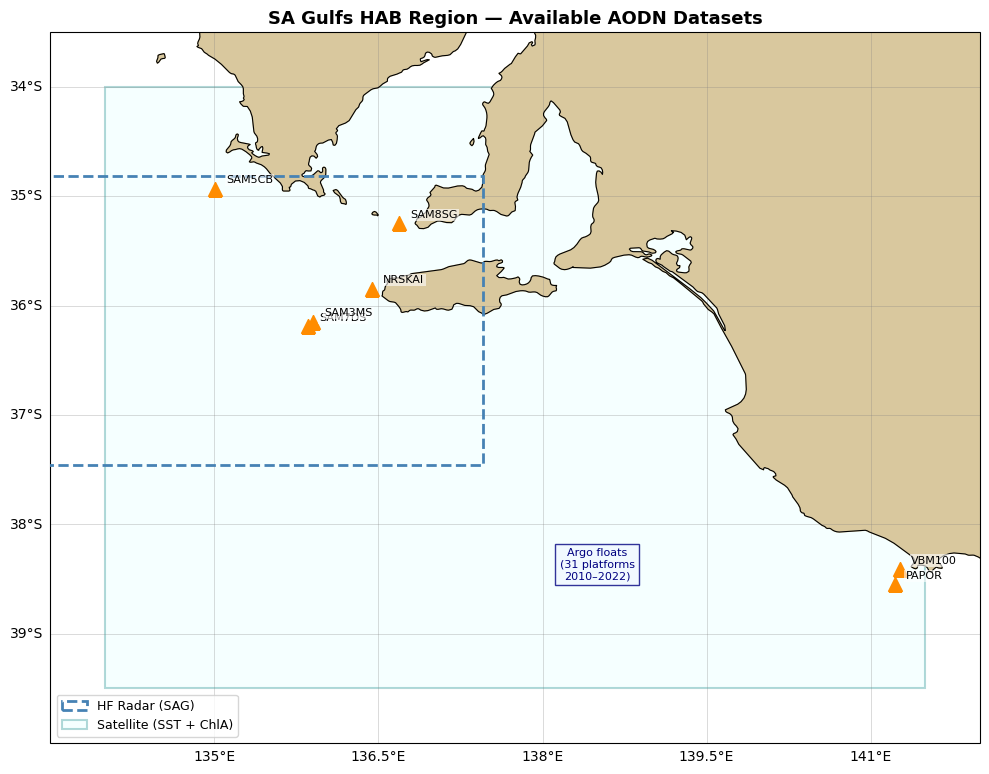

In [4]:
# Known mooring sites in the SA Gulfs region
MOORING_SITES = {
    'NRSKAI': (-35.845,  136.445, 'Kangaroo Is. NRS'),
    'SAM5CB': (-34.930,  135.006, 'SAM5 – Coffin Bay'),
    'SAM8SG': (-35.248,  136.689, 'SAM8 – Spencer Gulf'),
    'SAM7DS': (-36.189,  135.858, 'SAM7 – Dangerous Shoal'),
    'SAM3MS': (-36.146,  135.904, 'SAM3 – Middleton Shoal'),
    'PAPOR' : (-38.549,  141.219, 'Port of Portland'),
    'VBM100': (-38.409,  141.271, 'Victorian Blue-water Mooring'),
}

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([LON_MIN - 0.5, LON_MAX + 0.5, LAT_MIN - 0.5, LAT_MAX + 0.5], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, color='#d9c89e', zorder=2)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)
ax.add_feature(cfeature.BORDERS, linewidth=0.4, zorder=3)

# HF radar domain
from matplotlib.patches import Rectangle
radar_rect = plt.Polygon(
    [[132.95, -37.46],[137.46, -37.46],[137.46, -34.82],[132.95, -34.82]],
    closed=True, fill=False, edgecolor='steelblue', linewidth=2,
    linestyle='--', transform=ccrs.PlateCarree(), zorder=4, label='HF Radar (SAG)')
ax.add_patch(radar_rect)

# Satellite coverage
sat_rect = plt.Polygon(
    [[LON_MIN, LAT_MIN],[LON_MAX, LAT_MIN],[LON_MAX, LAT_MAX],[LON_MIN, LAT_MAX]],
    closed=True, facecolor='lightcyan', alpha=0.3, edgecolor='teal', linewidth=1.5,
    transform=ccrs.PlateCarree(), zorder=1, label='Satellite (SST + ChlA)')
ax.add_patch(sat_rect)

# Moorings
for code_s, (lat_s, lon_s, label_s) in MOORING_SITES.items():
    ax.plot(lon_s, lat_s, marker='^', color='darkorange', markersize=10,
            transform=ccrs.PlateCarree(), zorder=5)
    ax.text(lon_s + 0.1, lat_s + 0.05, code_s, fontsize=8,
            transform=ccrs.PlateCarree(), zorder=6,
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

# Argo approximate footprint indicator
ax.text(138.5, -38.5, 'Argo floats\n(31 platforms\n2010–2022)',
        fontsize=8, color='navy', ha='center', transform=ccrs.PlateCarree(),
        bbox=dict(facecolor='aliceblue', edgecolor='navy', alpha=0.8, pad=3))

gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.5)
gl.top_labels = gl.right_labels = False
ax.set_title(f'SA Gulfs HAB Region — Available AODN Datasets', fontsize=13, fontweight='bold')
ax.legend(loc='lower left', fontsize=9)
plt.tight_layout()
plt.show()


---
## 3 · Satellite SST (GHRSST L3S)

Daily 0.02° SST from IMOS/BoM GHRSST composite. Shows the surface thermal structure
of the gulfs — important for stratification, HAB growth rates, and upwelling signals.

> **Note:** Coords are lowercase (`lat`, `lon`, `time`); SST is in **Kelvin** (−273.15).


In [5]:
%%time
_fs = s3fs.S3FileSystem(anon=True)
ds_sst = xr.open_zarr(
    s3fs.S3Map('aodn-cloud-optimised/satellite_ghrsst_l3s_1day_daynighttime_multi_sensor_australia.zarr', s3=_fs),
    consolidated=True)

lat_sst = ds_sst.lat.values
lon_sst = ds_sst.lon.values
time_sst = ds_sst.time.values

# Pre-compute region indices (reused in later cells)
lat_i_sst = np.where((lat_sst >= LAT_MIN) & (lat_sst <= LAT_MAX))[0]
lon_i_sst = np.where((lon_sst >= LON_MIN) & (lon_sst <= LON_MAX))[0]
print(f"SST grid : {len(lat_i_sst)} lat × {len(lon_i_sst)} lon pixels")
print(f"Store    : {pd.Timestamp(time_sst[0]).strftime('%Y-%m-%d')} → {pd.Timestamp(time_sst[-1]).strftime('%Y-%m-%d')}")

SST grid : 275 lat × 375 lon pixels
Store    : 2012-01-01 → 2025-11-29
CPU times: user 714 ms, sys: 49.6 ms, total: 764 ms
Wall time: 1.49 s


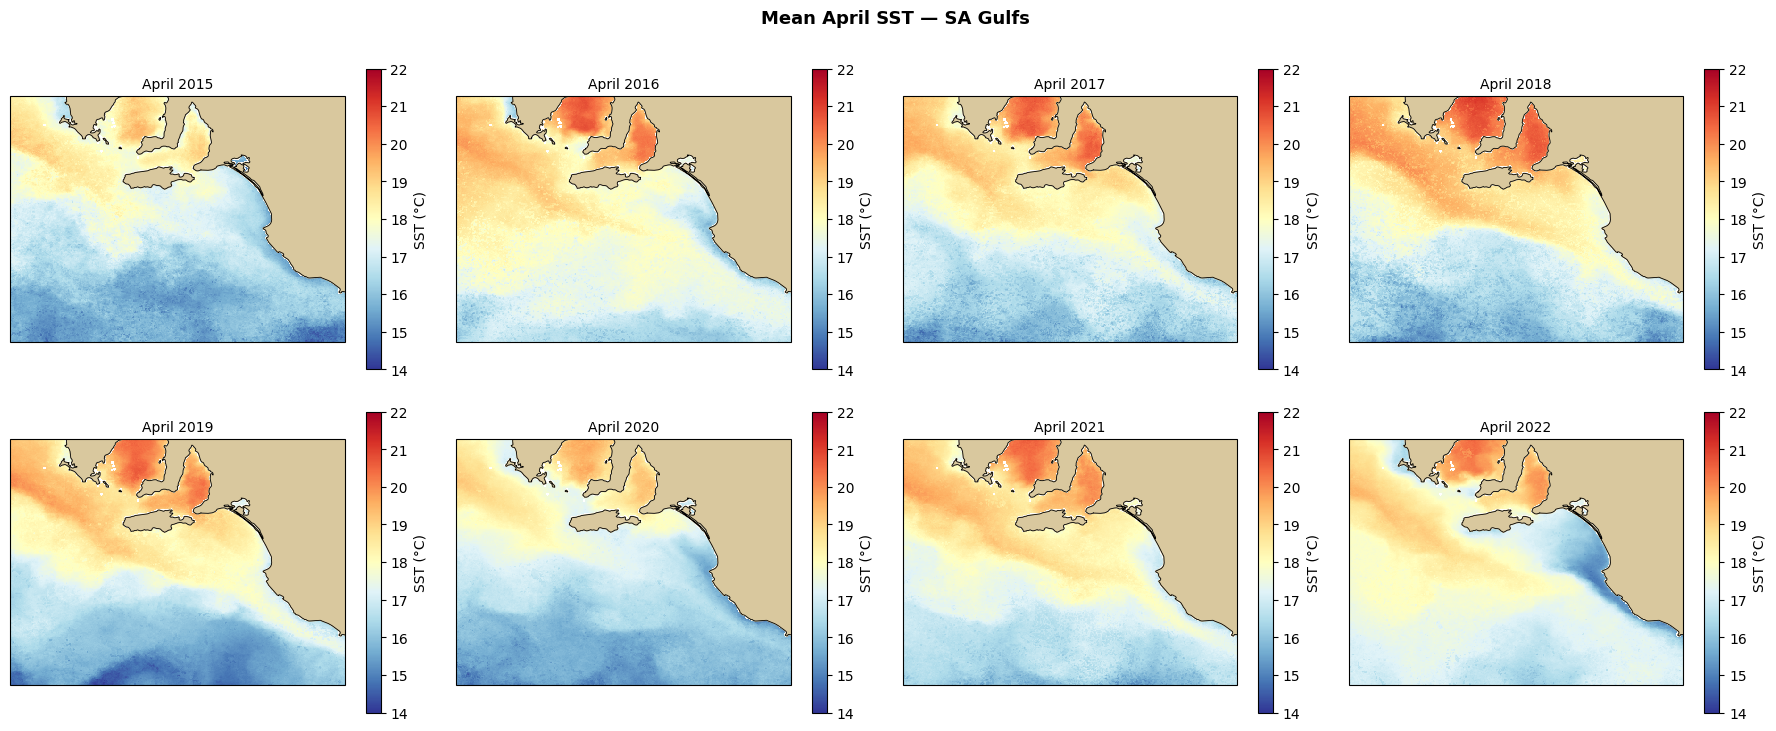

CPU times: user 3.63 s, sys: 492 ms, total: 4.12 s
Wall time: 6.77 s


In [6]:
%%time
# ── Mean SST map for each April year ─────────────────────────────────────────
ncols = min(4, len(YEARS))
nrows = int(np.ceil(len(YEARS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3.8 * nrows),
                          subplot_kw={'projection': ccrs.PlateCarree()})
axes = np.array(axes).ravel()

sst_monthly_means = {}          # store for later comparison panel
for ax, yr in zip(axes, YEARS):
    t_idx = np.where(
        (time_sst >= np.datetime64(f'{yr}-{ANALYSIS_MONTH:02d}-01')) &
        (time_sst <  _next_month_start(yr, ANALYSIS_MONTH))
    )[0]
    if len(t_idx) == 0:
        ax.set_visible(False); continue
    sst = ds_sst['sea_surface_temperature'].isel(
        time=t_idx,
        lat=slice(int(lat_i_sst[0]), int(lat_i_sst[-1])+1),
        lon=slice(int(lon_i_sst[0]), int(lon_i_sst[-1])+1)
    ).values - 273.15
    mean_sst = np.nanmean(sst, axis=0)
    sst_monthly_means[yr] = mean_sst
    im = ax.pcolormesh(lon_sst[lon_i_sst], lat_sst[lat_i_sst], mean_sst,
                       cmap='RdYlBu_r', vmin=14, vmax=22, transform=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, color='#d9c89e', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=3)
    ax.set_title(f'{MONTH_NAME} {yr}', fontsize=10)
    plt.colorbar(im, ax=ax, shrink=0.85, label='SST (°C)')

for ax in axes[len(YEARS):]:
    ax.set_visible(False)

fig.suptitle(f'Mean {MONTH_NAME} SST — SA Gulfs', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

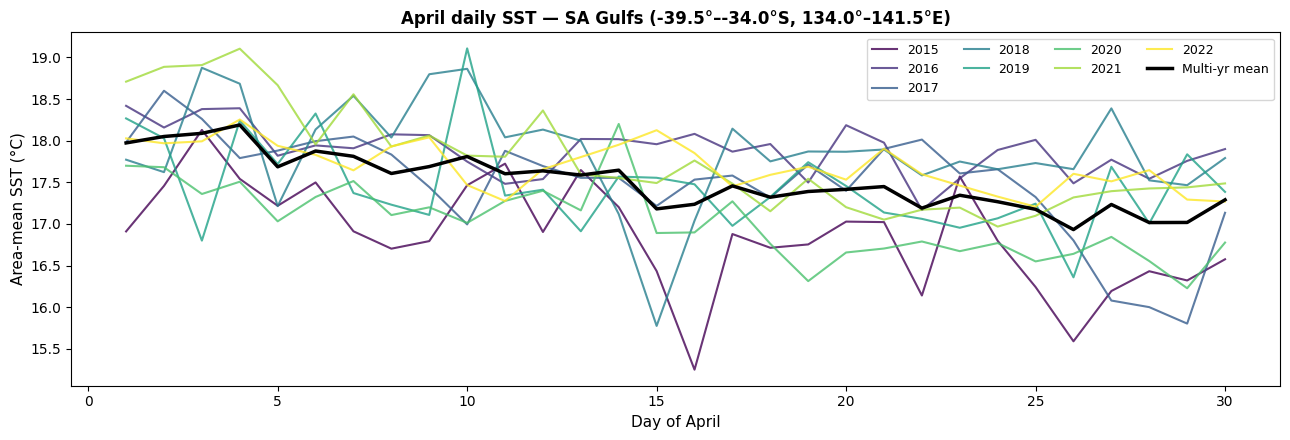

CPU times: user 2.26 s, sys: 334 ms, total: 2.6 s
Wall time: 4.84 s


In [7]:
%%time
# ── Area-mean SST daily timeseries, all years overlaid ───────────────────────
fig, ax = plt.subplots(figsize=(13, 4.5))
cmap_yr = plt.cm.viridis(np.linspace(0, 1, len(YEARS)))
all_daily_sst = {}

for col, yr in zip(cmap_yr, YEARS):
    t_idx = np.where(
        (time_sst >= np.datetime64(f'{yr}-{ANALYSIS_MONTH:02d}-01')) &
        (time_sst <  _next_month_start(yr, ANALYSIS_MONTH))
    )[0]
    if len(t_idx) == 0: continue
    sst = ds_sst['sea_surface_temperature'].isel(
        time=t_idx,
        lat=slice(int(lat_i_sst[0]), int(lat_i_sst[-1])+1),
        lon=slice(int(lon_i_sst[0]), int(lon_i_sst[-1])+1)
    ).values - 273.15
    daily = np.nanmean(sst, axis=(1, 2))
    all_daily_sst[yr] = daily
    ax.plot(np.arange(1, len(daily)+1), daily, color=col, lw=1.5, alpha=0.8, label=str(yr))

if all_daily_sst:
    max_len = max(len(v) for v in all_daily_sst.values())
    stacked = np.full((len(all_daily_sst), max_len), np.nan)
    for i, v in enumerate(all_daily_sst.values()): stacked[i, :len(v)] = v
    ax.plot(np.arange(1, max_len+1), np.nanmean(stacked, axis=0),
            color='black', lw=2.5, label='Multi-yr mean')

ax.set_xlabel(f'Day of {MONTH_NAME}', fontsize=11)
ax.set_ylabel('Area-mean SST (°C)', fontsize=11)
ax.set_title(f'{MONTH_NAME} daily SST — SA Gulfs ({LAT_MIN}°–{LAT_MAX}°S, {LON_MIN}°–{LON_MAX}°E)', fontsize=12, fontweight='bold')
ax.legend(ncol=4, fontsize=9)
plt.tight_layout()
plt.show()

---
## 4 · Satellite Chlorophyll-a (MODIS Aqua)

Daily 0.01° Chl-a concentration from the Carder bio-optical model.
Chlorophyll is the primary indicator of phytoplankton biomass and HAB risk.

> **Note:** Data ends **August 2022**. Coords are `latitude`, `longitude`, `time`.
> Apply `flags_carder == 0` quality mask. Use log scale.


In [8]:
%%time
ds_chl = xr.open_zarr(
    s3fs.S3Map('aodn-cloud-optimised/satellite_chlorophylla_carder_1day_aqua.zarr', s3=_fs),
    consolidated=True)

lat_chl = ds_chl.latitude.values
lon_chl = ds_chl.longitude.values
time_chl = ds_chl.time.values

lat_i_chl = np.where((lat_chl >= LAT_MIN) & (lat_chl <= LAT_MAX))[0]
lon_i_chl = np.where((lon_chl >= LON_MIN) & (lon_chl <= LON_MAX))[0]
print(f"ChlA grid: {len(lat_i_chl)} lat × {len(lon_i_chl)} lon pixels")
print(f"Store    : {pd.Timestamp(time_chl[0]).strftime('%Y-%m-%d')} → {pd.Timestamp(time_chl[-1]).strftime('%Y-%m-%d')}  (ends 2022)")

chl_years = [yr for yr in YEARS if yr <= 2022]
print(f"Years with ChlA data: {chl_years}")

ChlA grid: 551 lat × 751 lon pixels
Store    : 2002-07-04 → 2022-08-13  (ends 2022)
Years with ChlA data: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
CPU times: user 93.8 ms, sys: 56.2 ms, total: 150 ms
Wall time: 445 ms


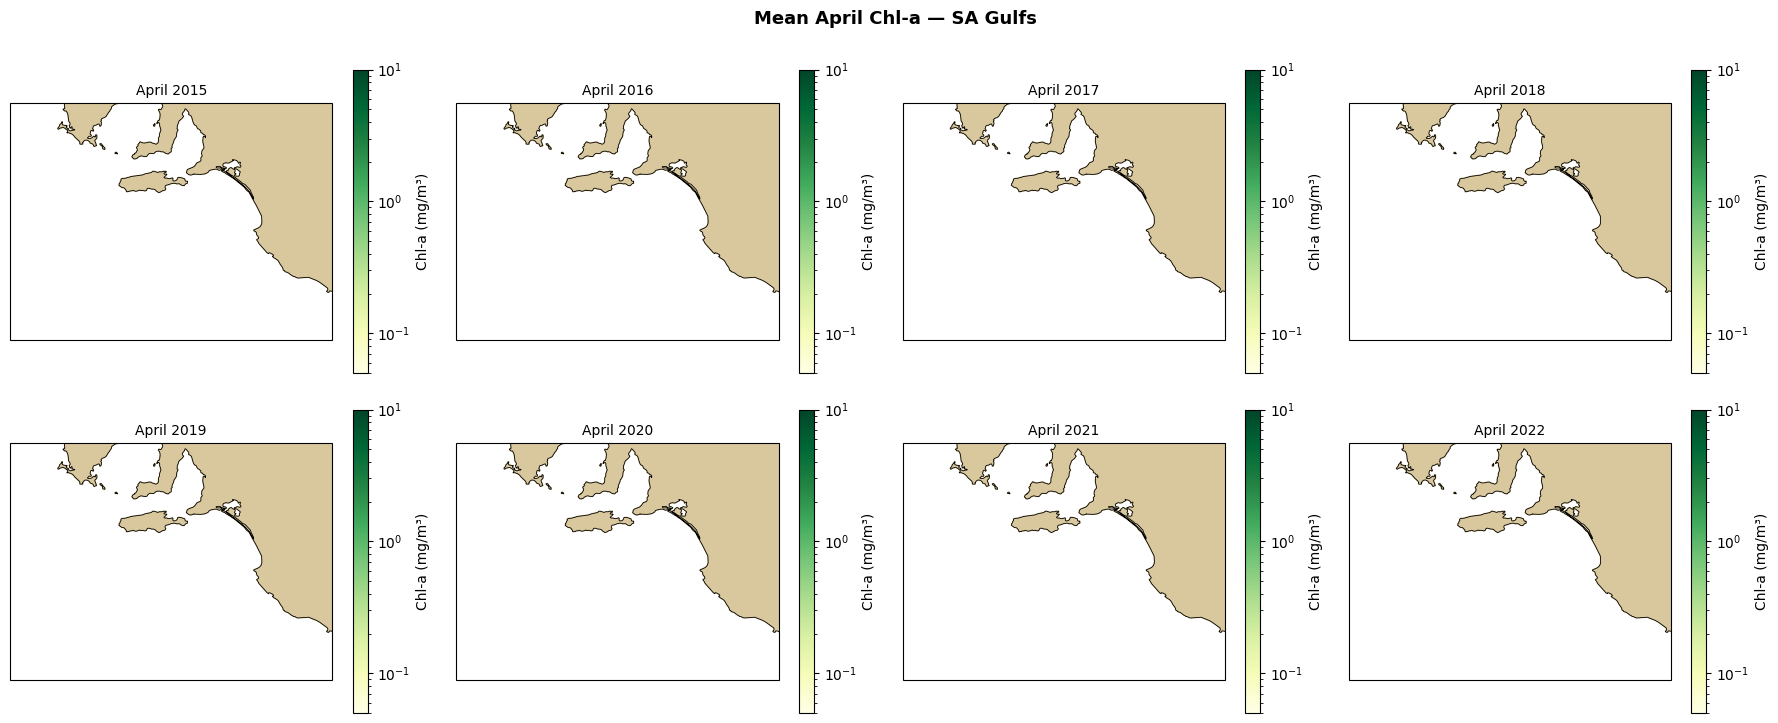

CPU times: user 15.3 s, sys: 2.17 s, total: 17.5 s
Wall time: 19 s


In [9]:
%%time
# ── Mean ChlA map per year ───────────────────────────────────────────────────
from matplotlib.colors import LogNorm

ncols = min(4, len(chl_years)) if chl_years else 1
nrows = int(np.ceil(len(chl_years) / ncols)) if chl_years else 1
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3.8 * nrows),
                          subplot_kw={'projection': ccrs.PlateCarree()})
axes = np.array(axes).ravel()

chl_monthly_means = {}
for ax, yr in zip(axes, chl_years):
    t_idx = np.where(
        (time_chl >= np.datetime64(f'{yr}-{ANALYSIS_MONTH:02d}-01')) &
        (time_chl <  _next_month_start(yr, ANALYSIS_MONTH))
    )[0]
    if len(t_idx) == 0: ax.set_visible(False); continue
    chl  = ds_chl['chl_carder'].isel(
        time=t_idx,
        latitude=slice(int(lat_i_chl[0]),  int(lat_i_chl[-1])+1),
        longitude=slice(int(lon_i_chl[0]), int(lon_i_chl[-1])+1)
    ).values
    flag = ds_chl['flags_carder'].isel(
        time=t_idx,
        latitude=slice(int(lat_i_chl[0]),  int(lat_i_chl[-1])+1),
        longitude=slice(int(lon_i_chl[0]), int(lon_i_chl[-1])+1)
    ).values
    chl = np.where((flag == 0) & (chl > 0), chl, np.nan)
    mean_chl = np.nanmean(chl, axis=0)
    chl_monthly_means[yr] = mean_chl
    im = ax.pcolormesh(lon_chl[lon_i_chl], lat_chl[lat_i_chl], mean_chl,
                       norm=LogNorm(vmin=0.05, vmax=10), cmap='YlGn',
                       transform=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, color='#d9c89e', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=3)
    ax.set_title(f'{MONTH_NAME} {yr}', fontsize=10)
    plt.colorbar(im, ax=ax, shrink=0.85, label='Chl-a (mg/m³)')

for ax in axes[len(chl_years):]:
    ax.set_visible(False)
fig.suptitle(f'Mean {MONTH_NAME} Chl-a — SA Gulfs', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

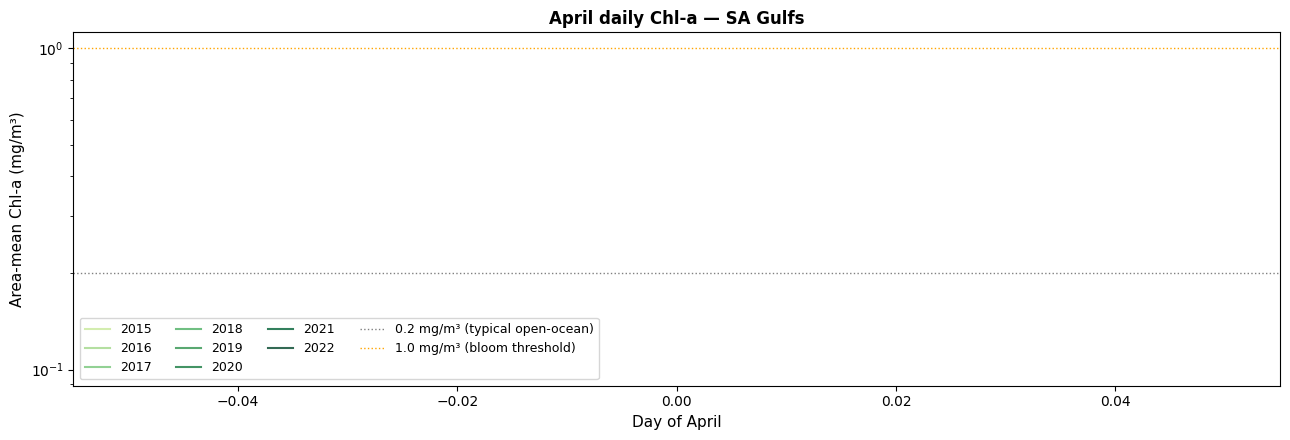

CPU times: user 13.1 s, sys: 1.85 s, total: 14.9 s
Wall time: 16.6 s


In [10]:
%%time
# ── Area-mean ChlA daily timeseries ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4.5))
cmap_yr = plt.cm.YlGn(np.linspace(0.3, 1.0, max(len(chl_years), 1)))
all_daily_chl = {}

for col, yr in zip(cmap_yr, chl_years):
    t_idx = np.where(
        (time_chl >= np.datetime64(f'{yr}-{ANALYSIS_MONTH:02d}-01')) &
        (time_chl <  _next_month_start(yr, ANALYSIS_MONTH))
    )[0]
    if len(t_idx) == 0: continue
    chl  = ds_chl['chl_carder'].isel(
        time=t_idx,
        latitude=slice(int(lat_i_chl[0]),  int(lat_i_chl[-1])+1),
        longitude=slice(int(lon_i_chl[0]), int(lon_i_chl[-1])+1)
    ).values
    flag = ds_chl['flags_carder'].isel(
        time=t_idx,
        latitude=slice(int(lat_i_chl[0]),  int(lat_i_chl[-1])+1),
        longitude=slice(int(lon_i_chl[0]), int(lon_i_chl[-1])+1)
    ).values
    chl = np.where((flag == 0) & (chl > 0), chl, np.nan)
    daily = np.nanmean(chl, axis=(1, 2))
    all_daily_chl[yr] = daily
    ax.plot(np.arange(1, len(daily)+1), daily, color=col, lw=1.5, alpha=0.8, label=str(yr))

ax.set_yscale('log')
ax.set_xlabel(f'Day of {MONTH_NAME}', fontsize=11)
ax.set_ylabel('Area-mean Chl-a (mg/m³)', fontsize=11)
ax.set_title(f'{MONTH_NAME} daily Chl-a — SA Gulfs', fontsize=12, fontweight='bold')
ax.axhline(0.2, color='gray', linestyle=':', lw=1, label='0.2 mg/m³ (typical open-ocean)')
ax.axhline(1.0, color='orange', linestyle=':', lw=1, label='1.0 mg/m³ (bloom threshold)')
ax.legend(ncol=4, fontsize=9)
plt.tight_layout()
plt.show()

---
## 5 · HF Radar — Surface Currents (SAG)

The IMOS WERA HF radar at South Australian Gulfs measures surface water velocity
(~0–1 m depth) at 1-hour intervals. Covers the area bounded by Kangaroo Island and
the Eyre Peninsula (~40,000 km²).

> **Note:** Spatial coverage is **132.95–137.46°E, 37.45–34.82°S** — slightly narrower than the full HAB bbox.


In [11]:
%%time
ds_vel = aodn.get_dataset('radar_SouthAustraliaGulfs_velocity_hourly_averaged_delayed_qc.zarr')
print("Radar velocity store loaded.")


Radar velocity store loaded.
CPU times: user 605 ms, sys: 58.9 ms, total: 664 ms
Wall time: 1.59 s


Rose period: 2015-04-01 → 2022-04-30


<Figure size 800x800 with 0 Axes>

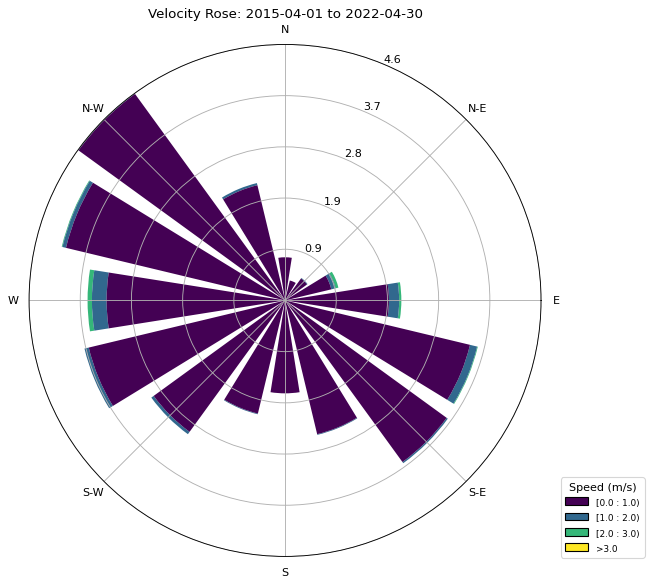

CPU times: user 16.2 s, sys: 1.16 s, total: 17.4 s
Wall time: 14.6 s


In [12]:
%%time
# ── Velocity rose: dominant current directions during analysis month ───────────
date_s = f'{YEAR_START}-{ANALYSIS_MONTH:02d}-01'
date_e = f'{YEAR_END}-{ANALYSIS_MONTH:02d}-{LAST_DAY:02d}'
print(f"Rose period: {date_s} → {date_e}")
ds_vel.plot_radar_water_velocity_rose(date_start=date_s, date_end=date_e)


Gridded snapshot: 2022-04-01


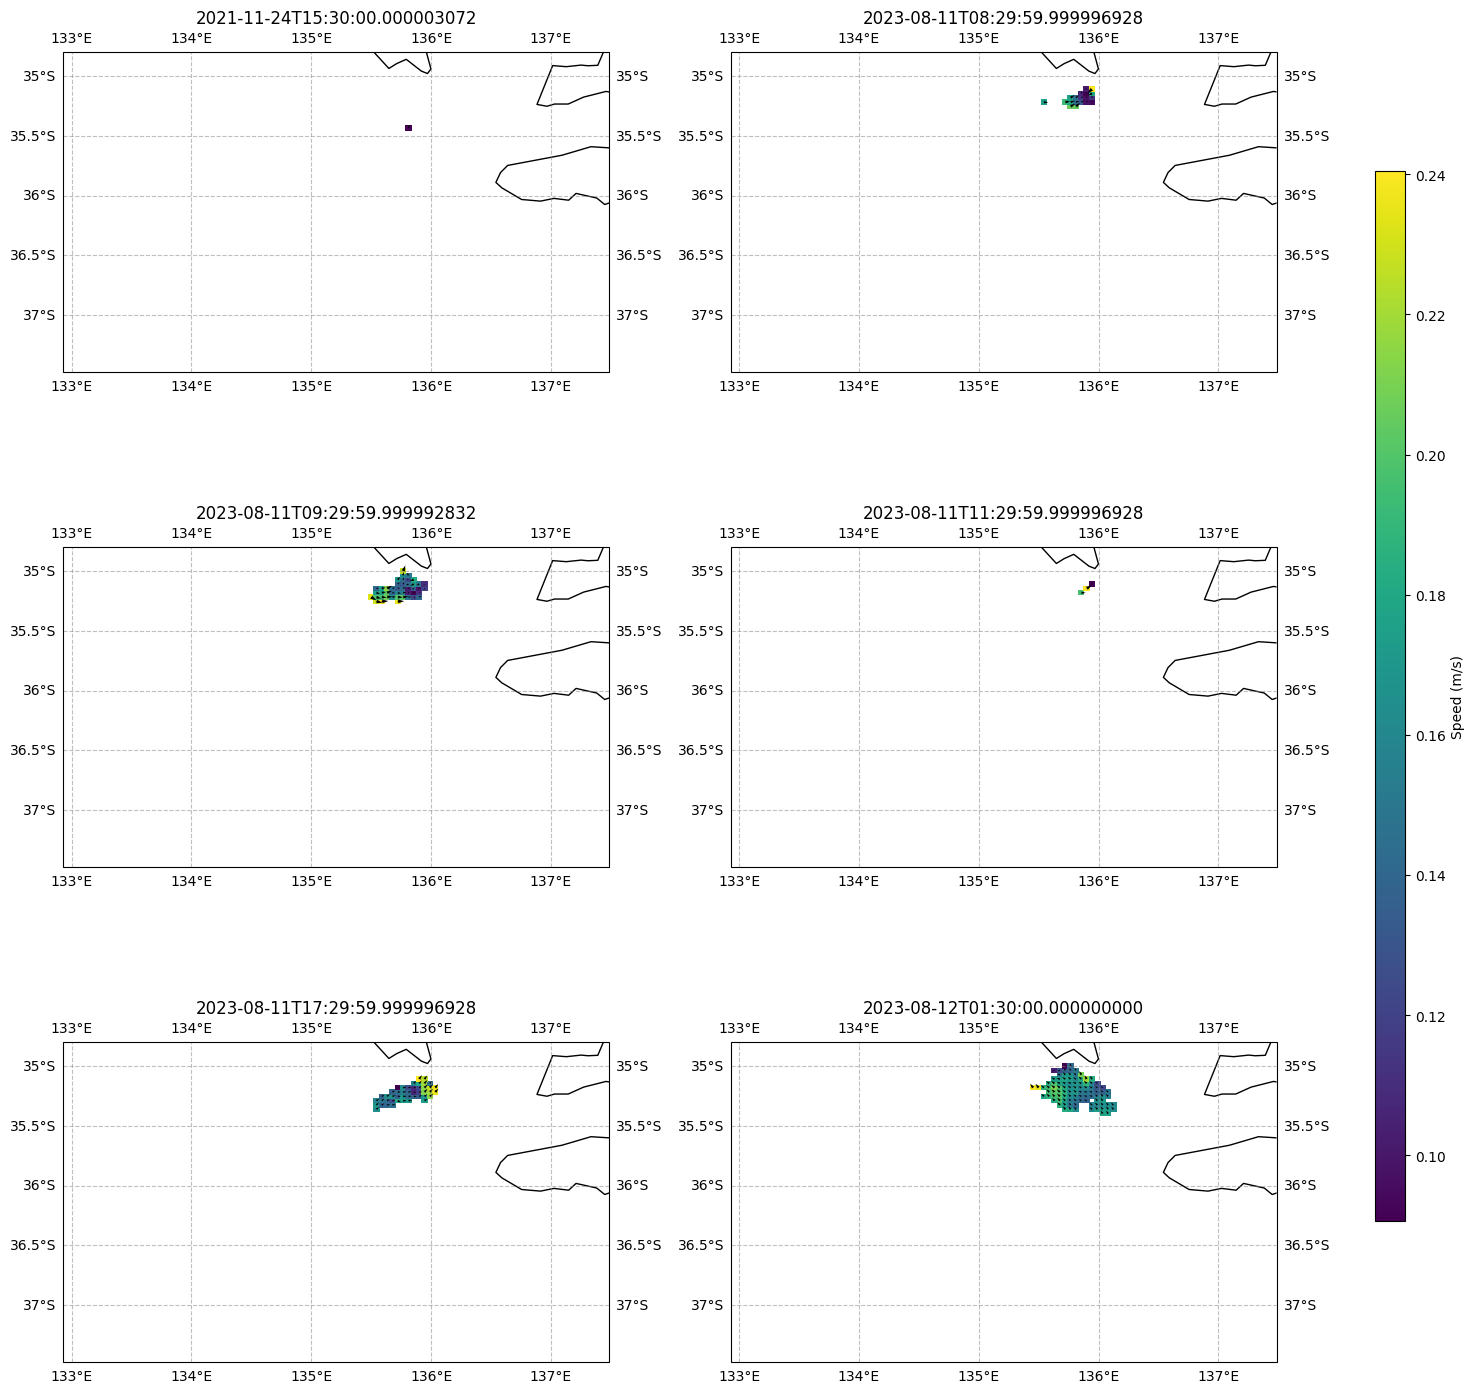

CPU times: user 5.79 s, sys: 1.7 s, total: 7.49 s
Wall time: 6.06 s


In [13]:
%%time
# ── Snapshot gridded map: first day of analysis month in last available year ──
# Find the most recent year with radar data (ends Feb 2024)
snap_year = min(YEAR_END, 2024)
snap_date = f'{snap_year}-{ANALYSIS_MONTH:02d}-01'
print(f"Gridded snapshot: {snap_date}")
ds_vel.plot_radar_water_velocity_gridded(date_start=snap_date)


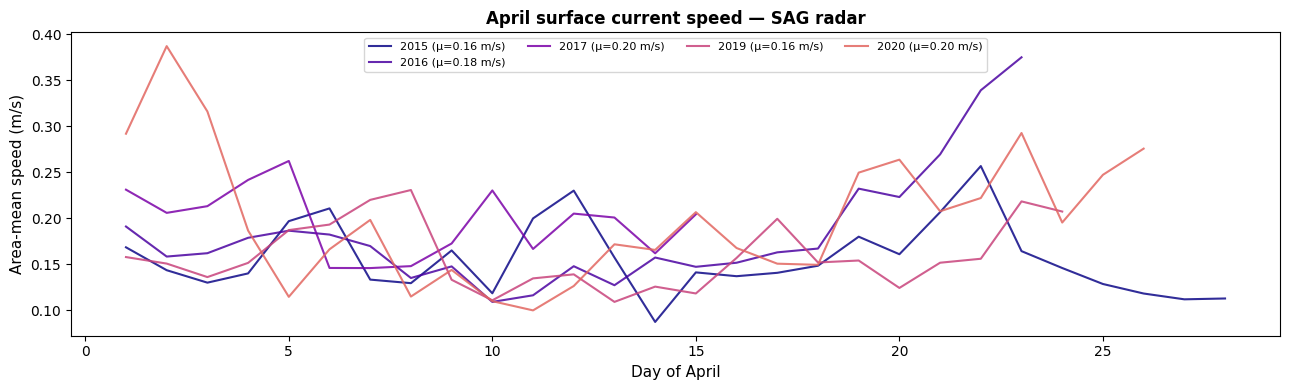

Annual mean current speeds: {2015: '0.156 m/s', 2016: '0.184 m/s', 2017: '0.196 m/s', 2019: '0.159 m/s', 2020: '0.201 m/s'}
CPU times: user 2.09 s, sys: 322 ms, total: 2.41 s
Wall time: 4.2 s


In [14]:
%%time
# ── Current speed timeseries: April mean per year ─────────────────────────────
zs_vel  = ds_vel.zarr_store
TIME_V  = zs_vel.TIME.values
LAT_V   = zs_vel.LATITUDE.values
LON_V   = zs_vel.LONGITUDE.values

lat_vi  = np.where((LAT_V >= LAT_MIN) & (LAT_V <= LAT_MAX))[0]
lon_vi  = np.where((LON_V >= LON_MIN) & (LON_V <= LON_MAX))[0]

fig, ax = plt.subplots(figsize=(13, 4))
cmap_v  = plt.cm.plasma(np.linspace(0, 0.85, len(YEARS)))
speed_annual_mean = {}

for col, yr in zip(cmap_v, YEARS):
    t0 = np.datetime64(f'{yr}-{ANALYSIS_MONTH:02d}-01')
    t1 = _next_month_start(yr, ANALYSIS_MONTH)
    t_vi = np.where((TIME_V >= t0) & (TIME_V < t1))[0]
    if len(t_vi) == 0: continue
    U = zs_vel['UCUR'].isel(TIME=t_vi,
                             LATITUDE=slice(int(lat_vi[0]), int(lat_vi[-1])+1),
                             LONGITUDE=slice(int(lon_vi[0]), int(lon_vi[-1])+1)).values
    V = zs_vel['VCUR'].isel(TIME=t_vi,
                             LATITUDE=slice(int(lat_vi[0]), int(lat_vi[-1])+1),
                             LONGITUDE=slice(int(lon_vi[0]), int(lon_vi[-1])+1)).values
    QCu = zs_vel['UCUR_quality_control'].isel(TIME=t_vi,
              LATITUDE=slice(int(lat_vi[0]), int(lat_vi[-1])+1),
              LONGITUDE=slice(int(lon_vi[0]), int(lon_vi[-1])+1)).values
    QCv = zs_vel['VCUR_quality_control'].isel(TIME=t_vi,
              LATITUDE=slice(int(lat_vi[0]), int(lat_vi[-1])+1),
              LONGITUDE=slice(int(lon_vi[0]), int(lon_vi[-1])+1)).values
    mask = (QCu == 1) & (QCv == 1)
    U[~mask] = np.nan; V[~mask] = np.nan
    spd = np.sqrt(U**2 + V**2)
    # Area-mean per timestep, then daily resample
    daily_spd = pd.Series(
        np.nanmean(spd, axis=(1, 2)),
        index=pd.to_datetime(TIME_V[t_vi])
    ).resample('1D').mean().dropna()
    speed_annual_mean[yr] = float(np.nanmean(daily_spd))
    ax.plot(np.arange(1, len(daily_spd)+1), daily_spd.values,
            color=col, lw=1.5, alpha=0.85, label=f'{yr} (μ={speed_annual_mean[yr]:.2f} m/s)')

ax.set_xlabel(f'Day of {MONTH_NAME}', fontsize=11)
ax.set_ylabel('Area-mean speed (m/s)', fontsize=11)
ax.set_title(f'{MONTH_NAME} surface current speed — SAG radar', fontsize=12, fontweight='bold')
ax.legend(ncol=4, fontsize=8)
plt.tight_layout()
plt.show()
print("Annual mean current speeds:", {k: f'{v:.3f} m/s' for k,v in speed_annual_mean.items()})

---
## 6 · HF Radar — Wave Field (SAG)

Wave parameters derived from the HF radar Doppler spectrum:
- **VAVH** — significant wave height (m)
- **WPPE** — peak wave period (s)
- **VDIRT** — dominant wave direction (°)

> **Note:** Wave data ends **December 2020**. Only years ≤ 2020 are analysed here.


In [15]:
%%time
ds_wave = aodn.get_dataset('radar_SouthAustraliaGulfs_wave_delayed_qc.zarr')
zs_wave = ds_wave.zarr_store
TIME_W  = zs_wave.TIME.values
LAT_W   = zs_wave.LATITUDE.values
LON_W   = zs_wave.LONGITUDE.values

lat_wi = np.where((LAT_W >= LAT_MIN) & (LAT_W <= LAT_MAX))[0]
lon_wi = np.where((LON_W >= LON_MIN) & (LON_W <= LON_MAX))[0]

# Find grid point with most valid VAVH data (across all April months ≤ 2020)
wave_years = [yr for yr in YEARS if yr <= 2020]
t_all_apr_w = np.where(
    np.isin(pd.to_datetime(TIME_W).month, [ANALYSIS_MONTH]) &
    (pd.to_datetime(TIME_W).year >= YEAR_START) &
    (pd.to_datetime(TIME_W).year <= min(YEAR_END, 2020))
)[0]
if len(t_all_apr_w) > 0:
    vavh_all = zs_wave['VAVH'].isel(
        TIME=t_all_apr_w,
        LATITUDE=slice(int(lat_wi[0]), int(lat_wi[-1])+1),
        LONGITUDE=slice(int(lon_wi[0]), int(lon_wi[-1])+1)
    ).values
    valid_count = np.sum(np.isfinite(vavh_all), axis=0)
    best_idx    = np.unravel_index(np.argmax(valid_count), valid_count.shape)
    best_lat_w  = LAT_W[lat_wi][best_idx[0]]
    best_lon_w  = LON_W[lon_wi][best_idx[1]]
    print(f"Best wave point: ({best_lat_w:.3f}°S, {best_lon_w:.3f}°E) "
          f"with {valid_count[best_idx]:,} valid records")
    print(f"Wave years with data: {wave_years}")
else:
    print("No wave radar data for the selected month/year range (data ends Dec 2020).")
    best_lat_w = best_lon_w = None


Best wave point: (-36.770°S, 136.066°E) with 1,041 valid records
Wave years with data: [2015, 2016, 2017, 2018, 2019, 2020]
CPU times: user 408 ms, sys: 92.1 ms, total: 500 ms
Wall time: 918 ms


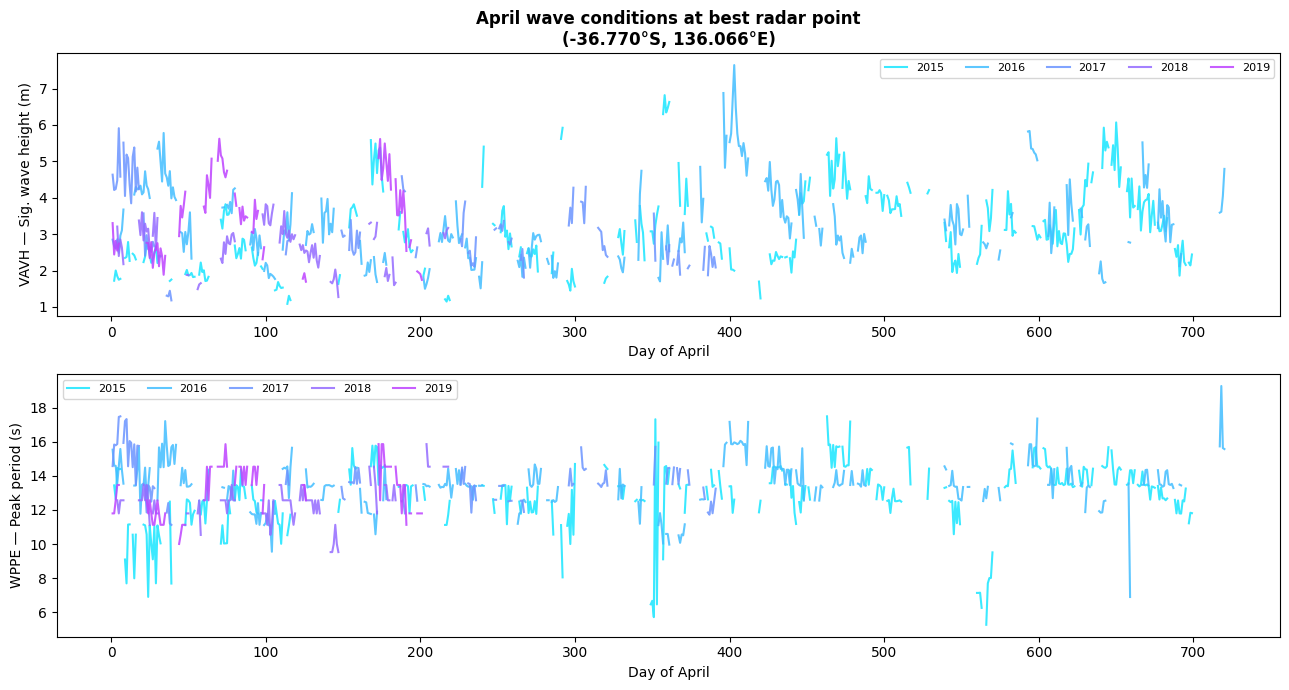

CPU times: user 710 ms, sys: 231 ms, total: 941 ms
Wall time: 1.13 s


In [16]:
%%time
if best_lat_w is not None and wave_years:
    fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=False)
    cmap_w = plt.cm.cool(np.linspace(0.1, 0.9, len(wave_years)))

    for col, yr in zip(cmap_w, wave_years):
        t0 = np.datetime64(f'{yr}-{ANALYSIS_MONTH:02d}-01')
        t1 = _next_month_start(yr, ANALYSIS_MONTH)
        t_wi2 = np.where((TIME_W >= t0) & (TIME_W < t1))[0]
        if len(t_wi2) == 0: continue
        best_lat_full_i = np.argmin(np.abs(LAT_W - best_lat_w))
        best_lon_full_i = np.argmin(np.abs(LON_W - best_lon_w))
        vavh = zs_wave['VAVH'].isel(TIME=t_wi2, LATITUDE=best_lat_full_i, LONGITUDE=best_lon_full_i).values
        wppe = zs_wave['WPPE'].isel(TIME=t_wi2, LATITUDE=best_lat_full_i, LONGITUDE=best_lon_full_i).values
        days = np.arange(1, len(vavh)+1)
        axes[0].plot(days, vavh, color=col, lw=1.5, alpha=0.85, label=str(yr))
        axes[1].plot(days, wppe, color=col, lw=1.5, alpha=0.85, label=str(yr))

    axes[0].set_ylabel('VAVH — Sig. wave height (m)', fontsize=10)
    axes[1].set_ylabel('WPPE — Peak period (s)', fontsize=10)
    for a in axes:
        a.set_xlabel(f'Day of {MONTH_NAME}', fontsize=10)
        a.legend(ncol=5, fontsize=8)
    axes[0].set_title(
        f'{MONTH_NAME} wave conditions at best radar point\n({best_lat_w:.3f}°S, {best_lon_w:.3f}°E)',
        fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Skipped: no wave radar data available for this month/year range.")

---
## 7 · Moorings — In-situ Temperature & Salinity

IMOS ANMN moorings provide hourly T/S at multiple depths.
Sites in the SA Gulfs region span 36–521 m depth, giving a partial subsurface picture
of seasonal water-column structure.

| Site | Lat | Lon | Max depth | Active |
|---|---|---|---|---|
| NRSKAI | 35.8°S | 136.4°E | 106 m | 2010–present |
| SAM5CB | 34.9°S | 135.0°E | 95 m | 2010–present |
| SAM8SG | 35.2°S | 136.7°E | 47 m | 2010–present |
| SAM7DS | 36.2°S | 135.9°E | 521 m | 2010–2014 |
| PAPOR  | 38.5°S | 141.2°E | 168 m | 2010–2017 |

> **Note:** TEMP and PSAL are the reliably populated variables.


In [17]:
%%time
ds_moor = aodn.get_dataset('mooring_hourly_timeseries_delayed_qc.parquet')
df_moor = ds_moor.get_data(
    date_start=f'{YEAR_START}-{ANALYSIS_MONTH:02d}-01',
    date_end  =f'{YEAR_END}-{ANALYSIS_MONTH:02d}-{LAST_DAY}',
    lat_min=LAT_MIN, lat_max=LAT_MAX, lon_min=LON_MIN, lon_max=LON_MAX
)
df_moor['TIME'] = pd.to_datetime(df_moor['TIME'])
print(f"Mooring records : {len(df_moor):,}")
print(f"Sites found     : {sorted(df_moor['site_code'].unique().tolist())}")
print(f"Depth range     : {df_moor['NOMINAL_DEPTH'].min():.0f} – {df_moor['NOMINAL_DEPTH'].max():.0f} m")


2026-03-23 15:14:28,513 - aodn.GetAodn - INFO - Retrieving metadata for aodn-cloud-optimised/mooring_hourly_timeseries_delayed_qc.parquet


Mooring records : 1,497,035
Sites found     : ['NRSKAI', 'PAPOR', 'SAM5CB', 'SAM8SG', 'VBM100']
Depth range     : 32 – 166 m
CPU times: user 5.03 s, sys: 2.03 s, total: 7.05 s
Wall time: 10.3 s


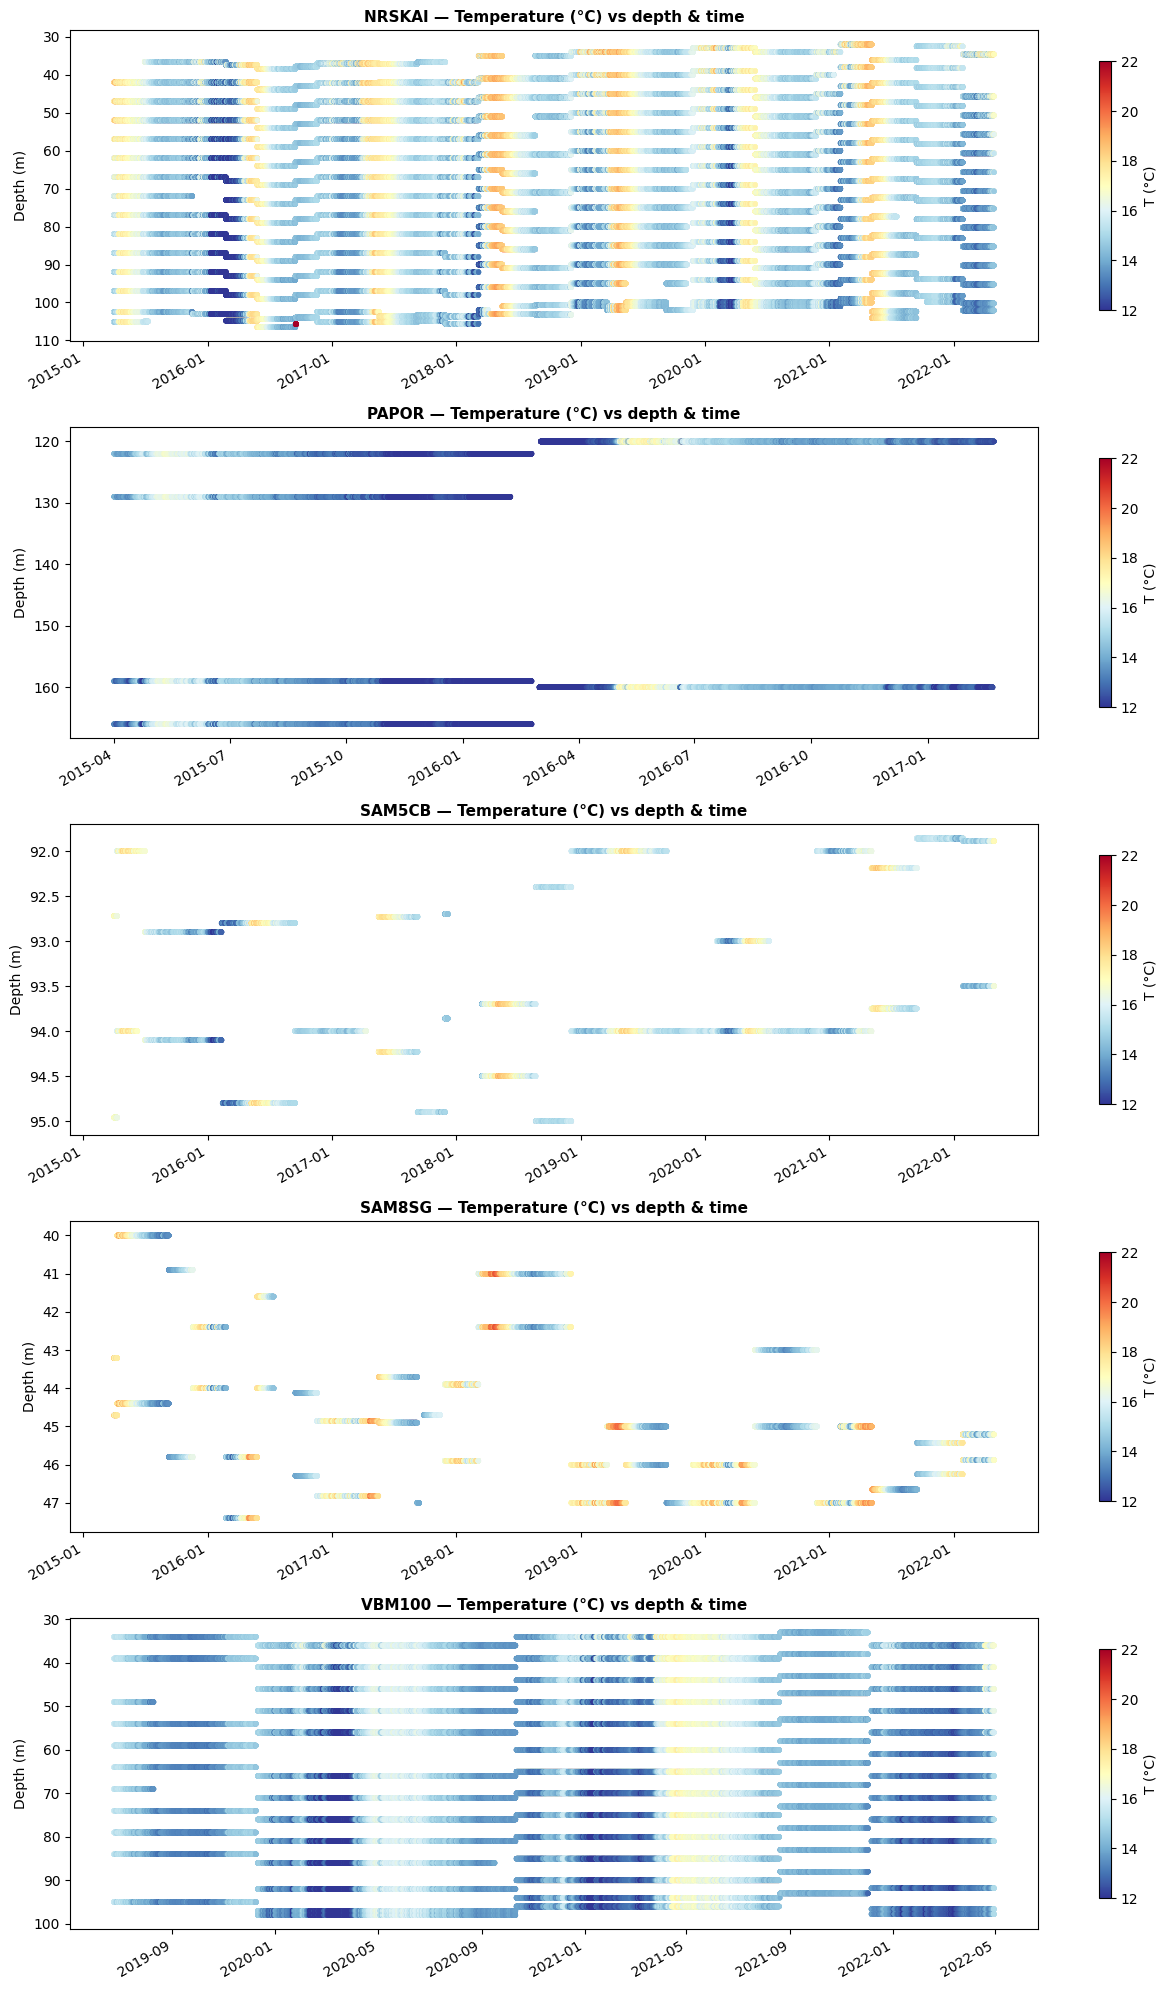

In [18]:
# ── Temperature depth-time heatmap per site ───────────────────────────────────
sites_found = sorted(df_moor['site_code'].unique())
fig, axes = plt.subplots(len(sites_found), 1, figsize=(13, 4 * len(sites_found)))
axes = np.array(axes).ravel() if len(sites_found) > 1 else [axes]

for ax, site in zip(axes, sites_found):
    df_s = df_moor[df_moor['site_code'] == site].copy()
    df_s = df_s[df_s['TEMP'].notna()].sort_values('TIME')
    if df_s.empty: ax.set_visible(False); continue
    sc = ax.scatter(df_s['TIME'], df_s['NOMINAL_DEPTH'], c=df_s['TEMP'],
                    cmap='RdYlBu_r', s=8, vmin=12, vmax=22)
    ax.set_ylim(ax.get_ylim()[::-1])   # depth increases downward
    ax.set_ylabel('Depth (m)', fontsize=10)
    ax.set_title(f'{site} — Temperature (°C) vs depth & time', fontsize=11, fontweight='bold')
    plt.colorbar(sc, ax=ax, label='T (°C)', shrink=0.8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()


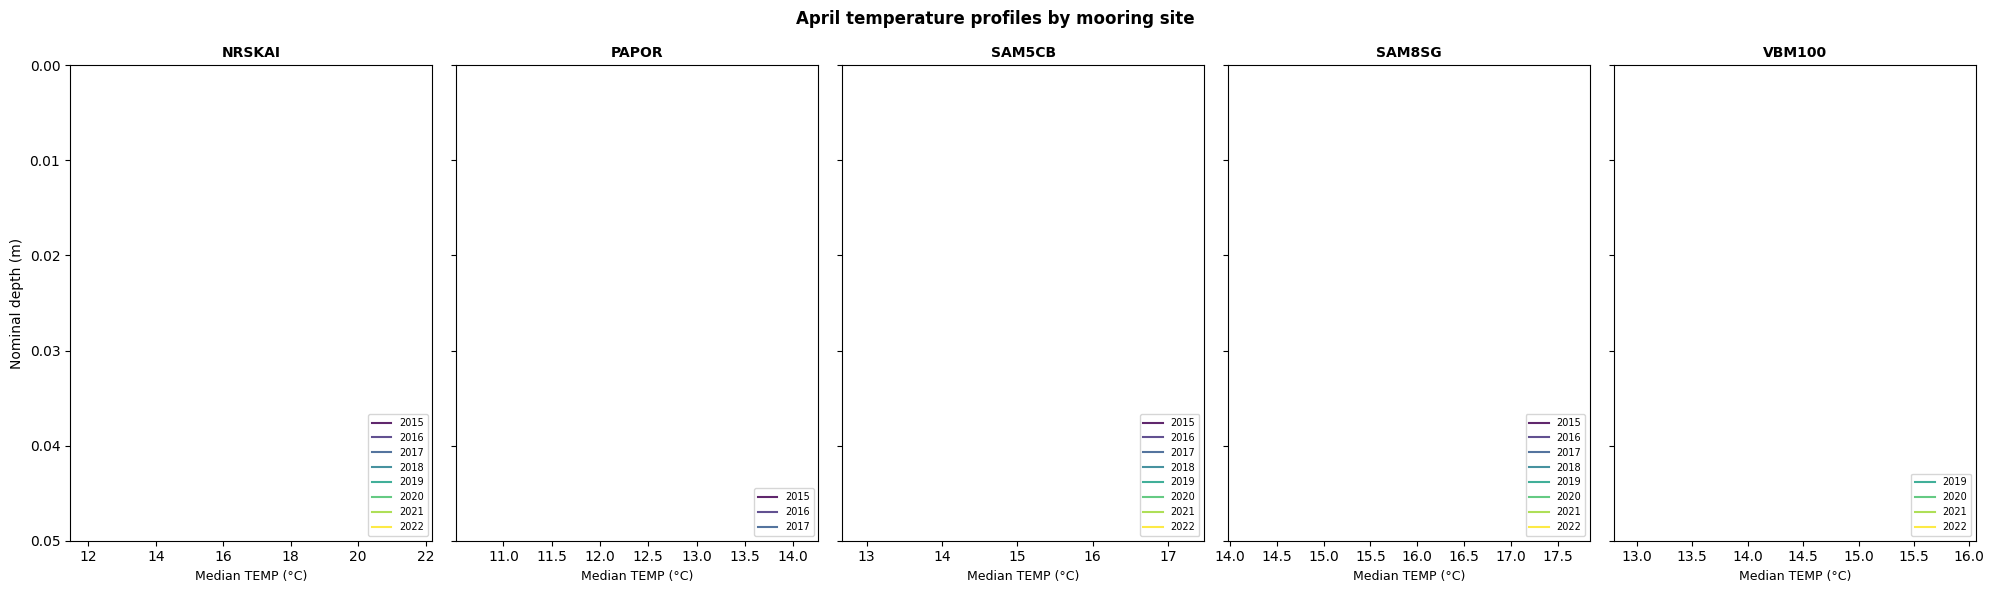

In [19]:
# ── Median T profile per site across all analysis years ──────────────────────
sites_found = sorted(df_moor['site_code'].unique())
fig, axes = plt.subplots(1, len(sites_found), figsize=(4 * len(sites_found), 6), sharey=True)
axes = np.array(axes).ravel() if len(sites_found) > 1 else [axes]

cmap_yr = plt.cm.viridis(np.linspace(0, 1, len(YEARS)))
for ax, site in zip(axes, sites_found):
    df_s = df_moor[df_moor['site_code'] == site]
    for col, yr in zip(cmap_yr, YEARS):
        df_yr = df_s[df_s['TIME'].dt.year == yr]
        if df_yr.empty: continue
        prof = df_yr.groupby('NOMINAL_DEPTH')['TEMP'].median()
        ax.plot(prof.values, prof.index, color=col, lw=1.5, alpha=0.85, label=str(yr))
    ax.set_ylim(bottom=ax.get_ylim()[1], top=0)
    ax.set_xlabel('Median TEMP (°C)', fontsize=9)
    ax.set_title(site, fontsize=10, fontweight='bold')
    ax.legend(fontsize=7, loc='lower right')

axes[0].set_ylabel('Nominal depth (m)', fontsize=10)
fig.suptitle(f'{MONTH_NAME} temperature profiles by mooring site', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 8 · Argo Floats — Subsurface Profiles (0–1000 m)

Argo core floats profile T and S from the surface to ~2000 m every ~10 days.
31 float platforms have visited the SA Gulfs during the record (2010–2022).
Filtered here to `TEMP_QC == '1'` and `PSAL_QC == '1'` (best quality).

> **Note:** Time column is `JULD`; QC flags are **strings** (`'1'` = good).


In [20]:
%%time
ds_argo = aodn.get_dataset('argo.parquet')
df_argo = ds_argo.get_data(
    date_start=f'{YEAR_START}-{ANALYSIS_MONTH:02d}-01',
    date_end  =f'{YEAR_END}-{ANALYSIS_MONTH:02d}-{LAST_DAY}',
    lat_min=LAT_MIN, lat_max=LAT_MAX, lon_min=LON_MIN, lon_max=LON_MAX
)
# QC filter (flags are strings) + limit to 1000 m
df_argo = df_argo[
    (df_argo['TEMP_QC'] == '1') & (df_argo['PSAL_QC'] == '1') &
    (df_argo['PRES'] <= 1000)
].copy()
print(f"Argo QC obs     : {len(df_argo):,}")
print(f"Floats          : {df_argo['PLATFORM_NUMBER'].nunique()}")
print(f"Depth range     : {df_argo['PRES'].min():.0f} – {df_argo['PRES'].max():.0f} dbar")
print(f"Date range      : {df_argo['JULD'].min()} → {df_argo['JULD'].max()}")


2026-03-23 15:14:55,067 - aodn.GetAodn - INFO - Retrieving metadata for aodn-cloud-optimised/argo.parquet


Argo QC obs     : 137,882
Floats          : 18
Depth range     : 2 – 1000 dbar
Date range      : 2015-04-04 06:25:57 → 2022-02-28 16:32:11.000000256
CPU times: user 4.85 s, sys: 422 ms, total: 5.27 s
Wall time: 15.8 s


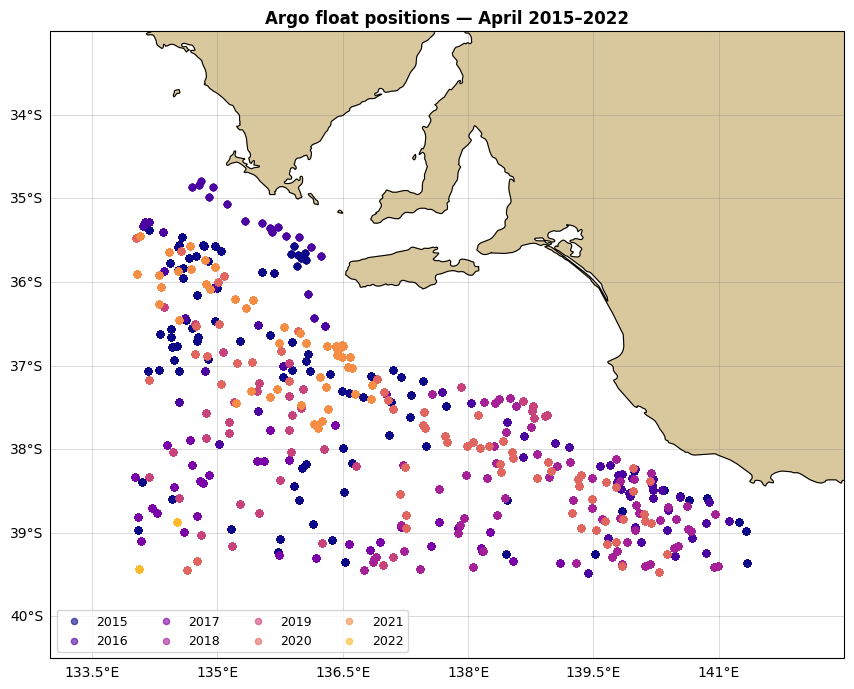

In [21]:
# ── Argo float locations map ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([LON_MIN - 1, LON_MAX + 1, LAT_MIN - 1, LAT_MAX + 1], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, color='#d9c89e', zorder=2)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)

cmap_yr_a = plt.cm.plasma(np.linspace(0, 0.85, len(YEARS)))
for col, yr in zip(cmap_yr_a, YEARS):
    df_yr = df_argo[df_argo['JULD'].dt.year == yr]
    if df_yr.empty: continue
    ax.scatter(df_yr['LONGITUDE'], df_yr['LATITUDE'],
               c=[col], s=20, alpha=0.6, transform=ccrs.PlateCarree(),
               label=str(yr), zorder=4)

gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.5)
gl.top_labels = gl.right_labels = False
ax.set_title(f'Argo float positions — {MONTH_NAME} {YEAR_START}–{YEAR_END}', fontsize=12, fontweight='bold')
ax.legend(ncol=4, fontsize=9, loc='lower left')
plt.tight_layout()
plt.show()


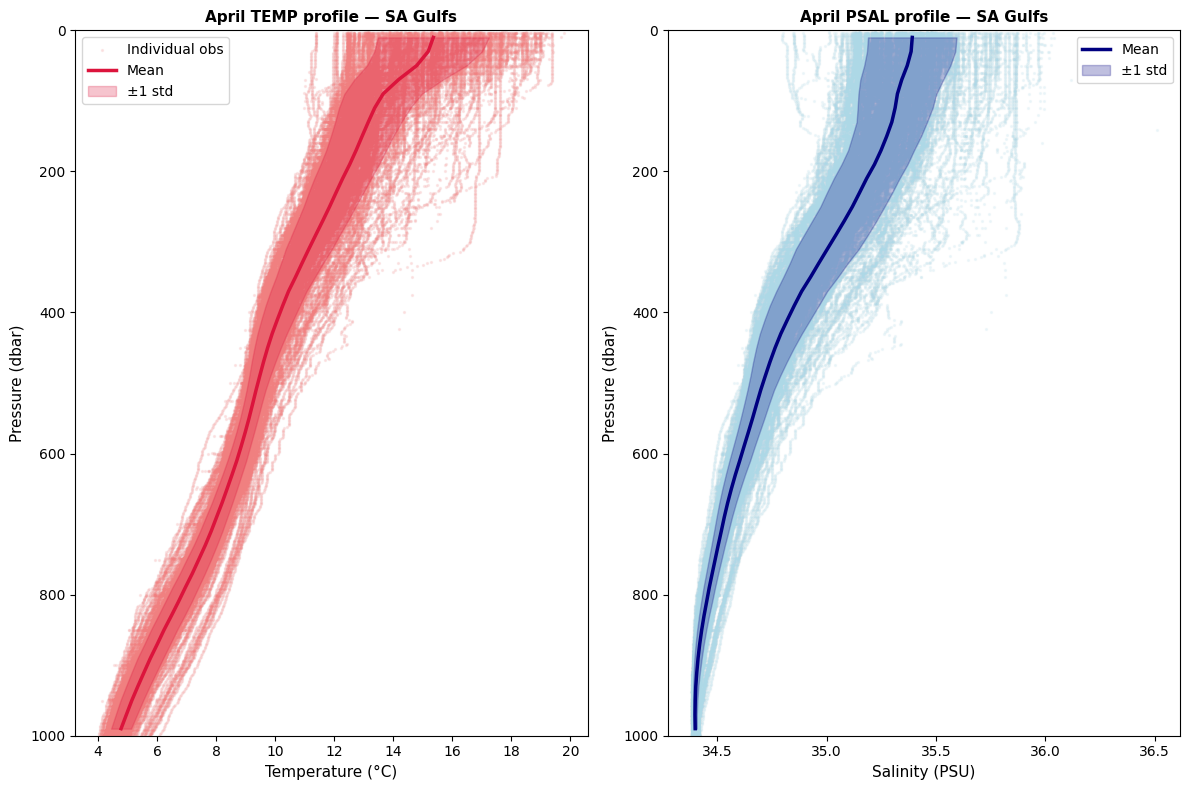

In [22]:
# ── T and S profiles to 1000 m ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 8))

# All individual profiles (light)
axes[0].scatter(df_argo['TEMP'], df_argo['PRES'], c='lightcoral', s=2, alpha=0.15, label='Individual obs')
axes[1].scatter(df_argo['PSAL'], df_argo['PRES'], c='lightblue',  s=2, alpha=0.15)

# Depth-binned mean ± std
depth_bins = np.arange(0, 1010, 20)
bin_centers = (depth_bins[:-1] + depth_bins[1:]) / 2
df_argo['depth_bin'] = pd.cut(df_argo['PRES'], bins=depth_bins, labels=bin_centers)

for ax, var, col, label in zip(axes, ['TEMP','PSAL'], ['crimson','navy'], ['Temperature (°C)','Salinity (PSU)']):
    stats = df_argo.groupby('depth_bin', observed=True)[var].agg(['mean','std'])
    ax.plot(stats['mean'], stats.index.astype(float), color=col, lw=2.5, label='Mean')
    ax.fill_betweenx(stats.index.astype(float),
                     stats['mean'] - stats['std'],
                     stats['mean'] + stats['std'],
                     color=col, alpha=0.25, label='±1 std')
    ax.invert_yaxis()
    ax.set_ylabel('Pressure (dbar)', fontsize=11)
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylim(1000, 0)
    ax.legend(fontsize=10)
    ax.set_title(f'{MONTH_NAME} {var} profile — SA Gulfs', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


T-S points: 137,882


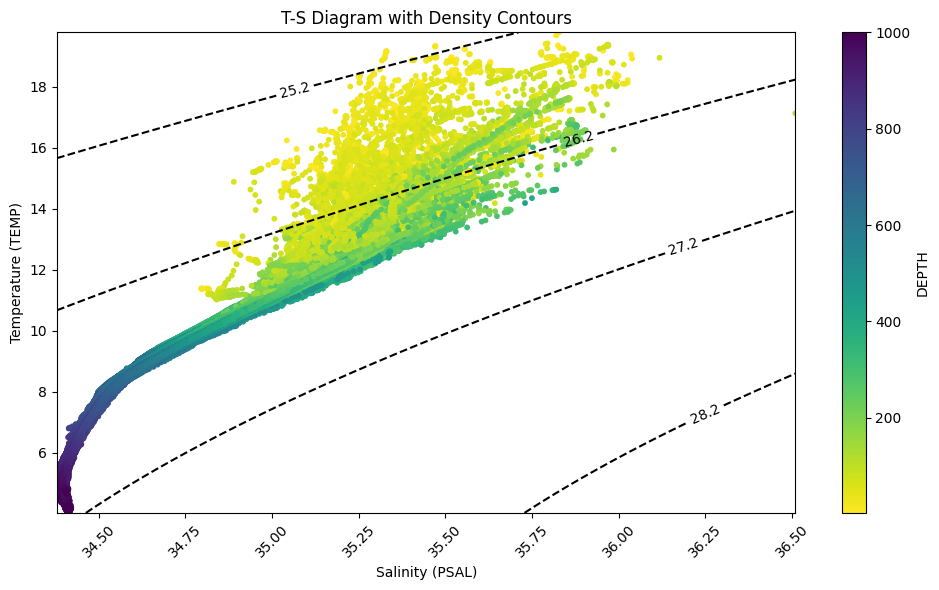

In [23]:
# ── T-S diagram ───────────────────────────────────────────────────────────────
df_ts = (df_argo[['TEMP','PSAL','PRES']]
         .dropna()
         .rename(columns={'PRES':'DEPTH'})
         .reset_index(drop=True))
print(f"T-S points: {len(df_ts):,}")
plot_ts_diagram(df_ts)

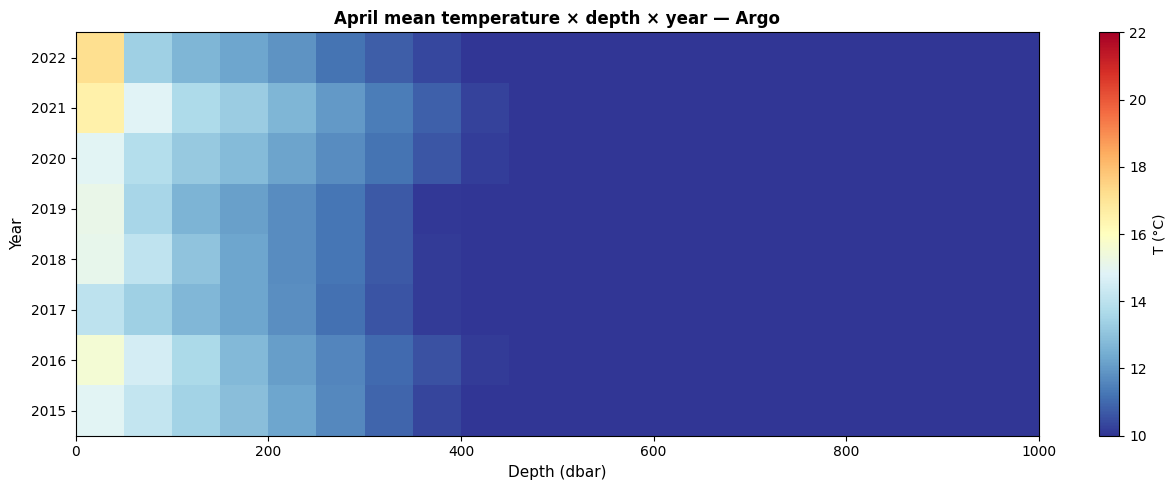

In [24]:
# ── Depth × year temperature heatmap (inter-annual subsurface variability) ────
depth_bins2 = np.arange(0, 1010, 50)
bin_centers2 = (depth_bins2[:-1] + depth_bins2[1:]) / 2
df_argo['depth_bin2'] = pd.cut(df_argo['PRES'], bins=depth_bins2, labels=bin_centers2.astype(int))
df_argo['year'] = df_argo['JULD'].dt.year

heatmap = df_argo.groupby(['year','depth_bin2'], observed=True)['TEMP'].mean().unstack('depth_bin2')
if not heatmap.empty:
    fig, ax = plt.subplots(figsize=(13, 5))
    im = ax.pcolormesh(heatmap.columns.astype(float), heatmap.index,
                       heatmap.values, cmap='RdYlBu_r', vmin=10, vmax=22)
    ax.set_xlabel('Depth (dbar)', fontsize=11)
    ax.set_ylabel('Year', fontsize=11)
    ax.set_title(f'{MONTH_NAME} mean temperature × depth × year — Argo', fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax, label='T (°C)')
    plt.tight_layout()
    plt.show()


---
## 9 · Slocum Glider (Optional)

ANFOG Slocum gliders profile T, S, Chl-a on high-resolution transects.
Coverage in the SA Gulfs is opportunistic — this section loads any available
deployments in the analysis period and region.


2026-03-23 15:15:43,063 - aodn.GetAodn - INFO - Retrieving metadata for aodn-cloud-optimised/slocum_glider_delayed_qc.parquet


Glider deployments found: ['Portland20160128' 'Portland20160229' 'Portland20170208'
 'Portland20170422' 'Portland20180209' 'Portland20180313'
 'Portland20190218' 'Portland20190923' 'Portland20210621'
 'SpencerGulf20150416' 'SpencerGulf20150528']


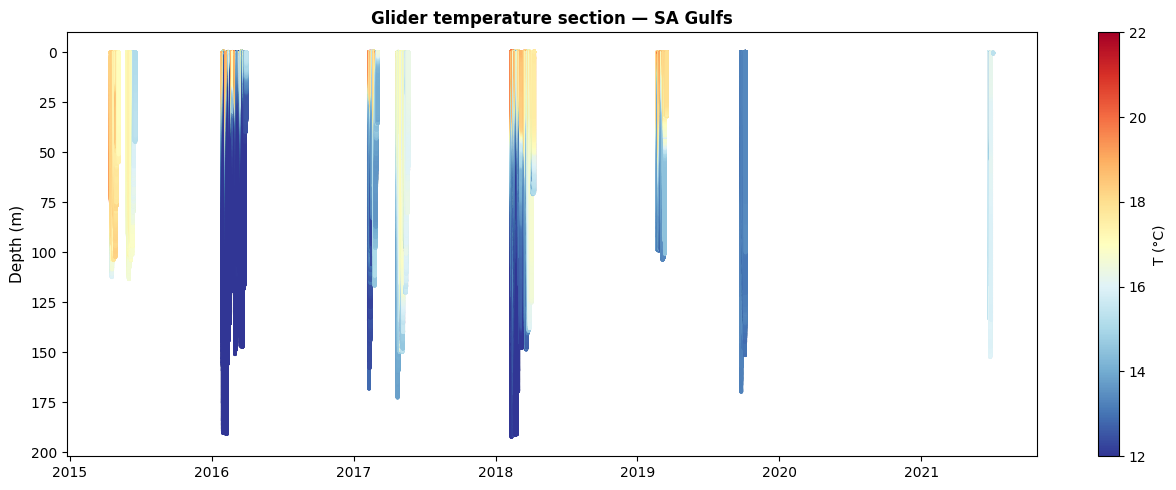

In [ ]:
%%time
try:
    ds_glider = aodn.get_dataset('slocum_glider_delayed_qc.parquet')
    df_glider = ds_glider.get_data(
        date_start=f'{YEAR_START}-{ANALYSIS_MONTH:02d}-01',
        date_end  =f'{YEAR_END}-{ANALYSIS_MONTH:02d}-{LAST_DAY}',
        lat_min=LAT_MIN, lat_max=LAT_MAX, lon_min=LON_MIN, lon_max=LON_MAX
    )
    if len(df_glider) == 0:
        print("No glider deployments found in SA Gulfs for the selected period.")
    else:
        df_glider = df_glider[(df_glider['TEMP_quality_control'] == 1.0) & df_glider['TEMP'].notna()]
        deps = df_glider['deployment_code'].unique()
        print(f"Glider deployments found: {deps}")
        fig, ax = plt.subplots(figsize=(13, 5))
        for dep in deps:
            d = df_glider[df_glider['deployment_code'] == dep].sort_values('TIME')
            sc = ax.scatter(d['TIME'], d['DEPTH'], c=d['TEMP'],
                            cmap='RdYlBu_r', s=3, vmin=12, vmax=22)
        ax.invert_yaxis()
        ax.set_ylabel('Depth (m)', fontsize=11)
        ax.set_title('Glider temperature section — SA Gulfs', fontsize=12, fontweight='bold')
        plt.colorbar(sc, ax=ax, label='T (°C)')
        plt.tight_layout()
        plt.show()
        # ChlA section if available
        df_chl_g = df_glider[df_glider['CPHL'].notna()] if 'CPHL' in df_glider.columns else pd.DataFrame()
        if not df_chl_g.empty:
            fig, ax = plt.subplots(figsize=(13, 4))
            sc = ax.scatter(df_chl_g['TIME'], df_chl_g['DEPTH'], c=df_chl_g['CPHL'],
                            cmap='YlGn', s=3, norm=LogNorm(vmin=0.05, vmax=5))
            ax.invert_yaxis()
            ax.set_ylabel('Depth (m)', fontsize=11)
            ax.set_title('Glider Chl-a section', fontsize=12, fontweight='bold')
            plt.colorbar(sc, ax=ax, label='Chl-a (mg/m³)')
            plt.tight_layout()
            plt.show()
except Exception as e:
    print(f"Glider data unavailable: {e}")


---
## 10 · Wave Buoy (Real-time, non-QC)

Real-time wave buoy data from ARDC/MHL. **Starts September 2022**, so only April 2023
onward is available. If your analysis window is earlier, this section will report no data.


In [ ]:
%%time
buoy_years = [yr for yr in YEARS if yr >= 2023]
if not buoy_years:
    print(f"Wave buoy data only available from April 2023 onward.\n"
          f"Your analysis ends {YEAR_END} — no buoy data in range.")
else:
    ds_buoy = aodn.get_dataset('wave_buoy_realtime_nonqc.parquet')
    df_buoy = ds_buoy.get_data(
        date_start=f'{min(buoy_years)}-{ANALYSIS_MONTH:02d}-01',
        date_end  =f'{max(buoy_years)}-{ANALYSIS_MONTH:02d}-{calendar.monthrange(max(buoy_years),ANALYSIS_MONTH)[1]}',
        lat_min=LAT_MIN, lat_max=LAT_MAX, lon_min=LON_MIN, lon_max=LON_MAX
    )
    if len(df_buoy) == 0:
        print("No wave buoy data found in SA Gulfs for this period.")
    else:
        df_buoy['TIME'] = pd.to_datetime(df_buoy['TIME'])
        print(f"Wave buoy records: {len(df_buoy):,}")
        print(f"Buoys: {df_buoy[['LATITUDE','LONGITUDE']].drop_duplicates().values}")
        fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
        for buoy_loc, grp in df_buoy.groupby(['LATITUDE','LONGITUDE']):
            grp = grp.sort_values('TIME')
            axes[0].plot(grp['TIME'], grp['WHTH'], lw=1.2, label=f'{buoy_loc[0]:.2f}°S {buoy_loc[1]:.2f}°E')
            axes[1].plot(grp['TIME'], grp['WPPE'], lw=1.2)
        axes[0].set_ylabel('Sig. wave height (m)', fontsize=10)
        axes[1].set_ylabel('Peak period (s)', fontsize=10)
        axes[0].legend(fontsize=8)
        axes[0].set_title(f'{MONTH_NAME} wave buoy — SA Gulfs', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()


---
## 11 · Integrated Overview

Multi-panel comparison of all daily-mean surface signals across the analysis period.
Useful for spotting coincident anomalies that may signal HAB conditions
(warm SST + elevated Chl-a + weak currents).


In [ ]:
# ── 4-panel daily timeseries, all years overlaid ──────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=False)

panels = [
    (all_daily_sst,  axes[0], 'Area-mean SST (°C)',          'RdYlBu_r', False),
    (all_daily_chl,  axes[1], 'Area-mean Chl-a (mg/m³)',     'YlGn',     True),
    (speed_records if 'speed_records' in dir() else {}, axes[2], 'Mean current speed (m/s)', 'plasma', False),
]

# Rebuild speed_records reference if needed
try:
    _sr = speed_records
except NameError:
    _sr = {}

for data_dict, ax, ylabel, cmap_name, log_scale in [
    (all_daily_sst,  axes[0], 'Area-mean SST (°C)',      'RdYlBu_r', False),
    (all_daily_chl,  axes[1], 'Area-mean Chl-a (mg/m³)', 'YlGn',     True),
    (_sr,            axes[2], 'Mean speed (m/s)',         'plasma',   False),
]:
    cmap_p = plt.get_cmap(cmap_name)
    colors_p = cmap_p(np.linspace(0.15, 0.85, max(len(data_dict), 1)))
    for col, (yr, vals) in zip(colors_p, data_dict.items()):
        vals_arr = vals.values if hasattr(vals, 'values') else np.array(vals)
        ax.plot(np.arange(1, len(vals_arr)+1), vals_arr, color=col, lw=1.5, alpha=0.8, label=str(yr))
    if log_scale: ax.set_yscale('log')
    ax.set_ylabel(ylabel, fontsize=10)
    ax.legend(ncol=5, fontsize=8)
    ax.set_xlabel(f'Day of {MONTH_NAME}', fontsize=10)

# Mooring NRSKAI surface temperature
df_nrs = df_moor[df_moor['site_code'] == 'NRSKAI'] if 'NRSKAI' in df_moor['site_code'].values else pd.DataFrame()
if not df_nrs.empty:
    surf = df_nrs[df_nrs['NOMINAL_DEPTH'] <= 5].copy()
    cmap_m = plt.cm.viridis(np.linspace(0, 1, len(YEARS)))
    for col, yr in zip(cmap_m, YEARS):
        d_yr = surf[surf['TIME'].dt.year == yr].resample('1D', on='TIME')['TEMP'].mean().dropna()
        if d_yr.empty: continue
        axes[3].plot(np.arange(1, len(d_yr)+1), d_yr.values, color=col, lw=1.5, alpha=0.85, label=str(yr))
    axes[3].set_ylabel('NRSKAI surface T (°C)', fontsize=10)
    axes[3].set_xlabel(f'Day of {MONTH_NAME}', fontsize=10)
    axes[3].legend(ncol=5, fontsize=8)
else:
    axes[3].text(0.5, 0.5, 'NRSKAI not in selected period', ha='center', va='center',
                 transform=axes[3].transAxes, fontsize=11)
    axes[3].set_visible(True)

fig.suptitle(f'{MONTH_NAME} {YEAR_START}–{YEAR_END} — SA Gulfs multi-dataset daily overview',
             fontsize=13, fontweight='bold', y=1.001)
plt.tight_layout()
plt.show()


In [ ]:
# ── Cartopy overview map: mean April SST + all platform locations ──────────────
# Use the most recent year's SST mean as background
bg_year = max(sst_monthly_means.keys()) if sst_monthly_means else None

fig, ax = plt.subplots(figsize=(11, 8), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([LON_MIN - 0.5, LON_MAX + 0.5, LAT_MIN - 0.5, LAT_MAX + 0.5], crs=ccrs.PlateCarree())

if bg_year:
    im = ax.pcolormesh(lon_sst[lon_i_sst], lat_sst[lat_i_sst],
                       sst_monthly_means[bg_year], cmap='RdYlBu_r',
                       vmin=14, vmax=22, transform=ccrs.PlateCarree(), alpha=0.85)
    plt.colorbar(im, ax=ax, shrink=0.75, label=f'SST (°C) — {MONTH_NAME} {bg_year}')

ax.add_feature(cfeature.LAND, color='#d9c89e', zorder=3)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=4)

# Mooring sites
for code_s, (lat_s, lon_s, label_s) in MOORING_SITES.items():
    ax.plot(lon_s, lat_s, '^', color='darkorange', markersize=12,
            transform=ccrs.PlateCarree(), zorder=5)
    ax.text(lon_s + 0.1, lat_s + 0.07, code_s, fontsize=8,
            transform=ccrs.PlateCarree(), zorder=6,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

# Argo positions
if not df_argo.empty:
    ax.scatter(df_argo['LONGITUDE'], df_argo['LATITUDE'],
               s=15, c='navy', alpha=0.4, transform=ccrs.PlateCarree(),
               zorder=5, label='Argo obs')

# HF radar domain
radar_rect2 = plt.Polygon(
    [[132.95,-37.46],[137.46,-37.46],[137.46,-34.82],[132.95,-34.82]],
    closed=True, fill=False, edgecolor='steelblue', linewidth=2.5,
    linestyle='--', transform=ccrs.PlateCarree(), zorder=6, label='HF Radar')
ax.add_patch(radar_rect2)

gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.5)
gl.top_labels = gl.right_labels = False
ax.set_title(f'{MONTH_NAME} {YEAR_START}–{YEAR_END} — SA Gulfs platform overview',
             fontsize=13, fontweight='bold')
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker='^', color='w', markerfacecolor='darkorange', markersize=10, label='Moorings'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='navy',       markersize=8,  label='Argo floats'),
    plt.Rectangle((0,0),1,1, fill=False, edgecolor='steelblue', linestyle='--', lw=2, label='HF Radar domain'),
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=9)
plt.tight_layout()
plt.show()
